# Supplementary: Qualitative Comparison - Ours (Stage-4 Path-B v2) vs CUPS

**Goal**: Visually demonstrate that our Stage-4 Path-B v2 model produces better unsupervised panoptic segmentation than the official CUPS model, across 4 driving-scene datasets.

## Outputs

For each dataset, we sample **20 images** and save one folder per image:

```
qualitative_results/
  cityscapes/
    <image_id>/
      original.png        # raw RGB, downsampled if needed
      ours_prediction.png                    # our raw colored panoptic prediction
      ours_overlay.png                       # our prediction overlaid on RGB
      ours_raw_panoptic.npz                  # channel 0 semantic ids + channel 1 thing instance ids
      ours_raw_semantic_ids.png              # uint16 semantic id map
      ours_raw_thing_instance_ids.png        # uint16 thing/instance id map, 0 = no thing
      ours_raw_thing_instance_ids_color.png  # colorized thing/instance ids for inspection
      cups_prediction.png                    # CUPS raw colored panoptic prediction
      cups_overlay.png                       # CUPS prediction overlaid on RGB
      cups_raw_panoptic.npz                  # CUPS channel 0 + channel 1 panoptic ids
      cups_raw_thing_instance_ids.png        # CUPS uint16 thing/instance id map
      triplet.png                            # Original Image | Ours Inference + Overlay | CUPS Inference + Overlay
      comparison.png                         # Original | Ours raw | Ours overlay | CUPS raw | CUPS overlay
      panoptic_metadata.json                 # per-image thing instance counts and id summaries
      source_path.txt                        # source RGB path for traceability
  kitti/
    <image_id>/...
  mapillary/
    <image_id>/...
  waymo/
    <segment>_<image_id>/...
  manifest.csv
  manifest.json
```

Each image is saved separately so individual figures can be lifted into the paper or supplementary directly.

## Batch runner

If you want to run the full export without a Jupyter kernel, use the script that mirrors this notebook:

```bash
/Users/qbit-glitch/Desktop/datasets/.venv_py310/bin/python \
  scripts/generate_qualitative_ours_vs_cups.py \
  --datasets cityscapes kitti mapillary waymo \
  --n-images 20
```

## Models

- **Ours**: DINOv3 ViT-B/16 + Cascade Mask R-CNN, Stage-4 Path-B v2 `best_pq_step=000575.ckpt` (39.13 PQ on local Cityscapes val; +11.33 over CUPS).
- **CUPS**: Official DINO ResNet-50 + Cascade Mask R-CNN (27.80 PQ on Cityscapes val).

## Notes on Devices

Detectron2's Cascade Mask R-CNN has limited support on Apple MPS. Default is **CPU**, which is slower but reliable. Override `DEVICE` below if you have CUDA.

## Why `SEMANTIC_MAPPING = 'cityscapes27'`

Both models are rendered through `cups.visualization.semantic_segmentation_to_rgb(dataset='cityscapes')`, which has only a **28-color palette**. Ours has 80 raw pseudo-clusters (16 things + 64 stuff) and CUPS has 27 (5 + 22). With `SEMANTIC_MAPPING='raw'`, Ours' IDs >=27 collapse to **black** (the void color at palette index 27), making Ours look catastrophically worse than CUPS even though it wins by +8 PQ on the benchmark. `cityscapes27` runs the same Hungarian assignment used by the PQ metric, mapping both models into a 0..26 range that fits the palette correctly. Use raw mode only for inspecting individual cluster behavior, never for cross-model comparison.

## 0. Setup

In [13]:
from pathlib import Path
import os, sys, gc, random, csv, json

# Project paths
PROJECT_ROOT = Path('/Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation')
CUPS_ROOT    = PROJECT_ROOT / 'refs' / 'cups'
DATASETS_ROOT = Path('/Users/qbit-glitch/Desktop/datasets')
OUTPUT_ROOT   = PROJECT_ROOT / 'notebooks' / 'qualitative_results'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Keep matplotlib cache inside the workspace when HOME is sandboxed/read-only.
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib-cache'))
os.environ['WANDB_MODE'] = 'disabled'

import numpy as np
import torch
import torchvision.io
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Sys path
for p in [PROJECT_ROOT, CUPS_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Device - CPU is the most reliable for Detectron2 on macOS.
# Override to 'cuda' if you have an NVIDIA GPU; 'mps' may crash for some panoptic ops.
if torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

# Number of images per dataset
N_IMAGES = 20

# Maximum short-side for the input image (keeps inference RAM reasonable on CPU)
MAX_SHORT_SIDE = 640
MODEL_SIZE_DIVISOR = 64

# Use Cityscapes-27 Hungarian remapping so both models are rendered in the same 27-class color space.
# Raw mode is unsafe for cross-model comparison: Ours has 80 pseudo-clusters but the cityscapes palette
# only has 28 entries, so all Ours IDs >=27 collapse to black while CUPS' 27 IDs all hit valid colors.
SEMANTIC_MAPPING = 'cityscapes27'
ASSIGNMENT_IMAGES = 0  # 0 = full 500-image Cityscapes val assignment (paper-quality); set 50-100 for fast verification
# Path-B has its own pseudo-cluster -> Cityscapes-27 assignment; new cache file so we
# don't accidentally reuse the Stage-3 Hungarian mapping.
ASSIGNMENT_CACHE = OUTPUT_ROOT / '_semantic_assignments_cityscapes27_stage4_pathB_focal_w005_gated_v2_step575_all.json'
DRAW_INSTANCE_IDS = False  # cleaner paper figures; set True to print instance IDs on masks

# Visualization-only: fill panoptic combine-logic abstention (semantic id == 255) with the spatially
# nearest non-void pixel before rendering PNGs. Raw artifacts (npz, uint16 PNG) preserve the original
# void mask. PQ evaluation pipeline is unaffected (different code path). Set False to render raw void.
FILL_VOID = True

# Checkpoint paths
# Path-B Stage-4 v2 (thing_focal_only + WEIGHT=0.05 + teacher-agreement gating) at opt step 575.
# Local eval: PQ=39.13, PQ_things=42.10, PQ_stuff=37.27, mIoU=45.92. +11.33 PQ over CUPS.
OURS_CKPT = PROJECT_ROOT / 'checkpoints' / 'stage4_pathB_focal_w005_gated_v2' / 'best_pq_step=000575.ckpt'
CUPS_CKPT = PROJECT_ROOT / 'weights' / 'cups.ckpt'

# Config matches the Stage-4 Path-B checkpoint. Architecture is identical to Stage-3
# (DINOv3 ViT-B/16 + Cascade Mask R-CNN); only the Stage-4 fine-object loss config + WEIGHT differ.
# Model loading uses MODEL.CHECKPOINT only, so DATA paths in this yaml (santosh-remote) don't
# affect local inference here.
OURS_CFG = CUPS_ROOT / 'configs' / 'val_stage4_fine_object_local.yaml'

for label, path in [('Ours ckpt', OURS_CKPT), ('CUPS ckpt', CUPS_CKPT), ('Ours cfg', OURS_CFG)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'{label:10s}: {path} [{status}]')

assert OURS_CKPT.exists(), f'Missing our checkpoint: {OURS_CKPT}'
assert CUPS_CKPT.exists(), f'Missing CUPS checkpoint: {CUPS_CKPT}'
assert OURS_CFG.exists(),  f'Missing our config: {OURS_CFG}'

Using device: cpu
Ours ckpt : /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/checkpoints/stage4_pathB_focal_w005_gated_v2/best_pq_step=000575.ckpt [OK]
CUPS ckpt : /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/weights/cups.ckpt [OK]
Ours cfg  : /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/refs/cups/configs/val_stage4_fine_object_local.yaml [OK]


## 1. Load Both Models

- CUPS official: ResNet-50 backbone — loaded via `panoptic_cascade_mask_r_cnn_from_checkpoint`.
- Ours: DINOv3 ViT-B/16 backbone — loaded via `cups.build_model_self` with the Stage-4 Path-B v2 checkpoint.

Both produce panoptic predictions in the form `(H, W, 2)` with channel 0 = semantic id and channel 1 = instance id.

In [14]:
# --- Load CUPS official (ResNet-50 backbone) ----------------------------
from cups.model import (
    panoptic_cascade_mask_r_cnn_from_checkpoint,
    prediction_to_standard_format,
)

cups_model, cups_n_things, cups_n_stuff = panoptic_cascade_mask_r_cnn_from_checkpoint(
    path=str(CUPS_CKPT),
    device=DEVICE,
    confidence_threshold=0.5,
)
cups_model = cups_model.to(DEVICE).eval()
cups_stuff_classes = tuple(range(cups_n_stuff))
cups_thing_classes = tuple(range(cups_n_stuff, cups_n_stuff + cups_n_things))
print(f'CUPS loaded: {cups_n_things} things + {cups_n_stuff} stuff clusters')

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: False
  NUM_WORKERS: 4
  REPEAT_SQRT: True
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val_panoptic_separated',)
  TRAIN: ('coco_2017_train_panoptic_separated',)
FLOAT32_PRECISION: 
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (640, 672, 704, 736, 768, 800)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 0
    NAME: build_resnet_f

In [15]:
# --- Load Ours (DINOv3 ViT-B/16 backbone) -------------------------------
import cups
from cups.augmentation import PhotometricAugmentations, ResolutionJitter
from cups.data import (
    CITYSCAPES_THING_CLASSES,
    CITYSCAPES_STUFF_CLASSES,
    CITYSCAPES_CLASSNAMES,
)
from pytorch_lightning import seed_everything

config = cups.get_default_config(experiment_config_file=str(OURS_CFG))
config.defrost()
config.MODEL.CHECKPOINT = str(OURS_CKPT)
config.SYSTEM.ACCELERATOR = DEVICE if not DEVICE.startswith('cuda') else 'gpu'
config.freeze()
seed_everything(config.SYSTEM.SEED, verbose=False)

ours_model = cups.build_model_self(
    config=config,
    thing_classes=CITYSCAPES_THING_CLASSES,
    stuff_classes=CITYSCAPES_STUFF_CLASSES,
    thing_pseudo_classes=None,
    stuff_pseudo_classes=None,
    class_weights=None,
    class_names=CITYSCAPES_CLASSNAMES,
    photometric_augmentation=PhotometricAugmentations(),
    freeze_bn=True,
    resolution_jitter_augmentation=ResolutionJitter(
        scales=None,
        resolutions=config.AUGMENTATION.RESOLUTIONS,
    ),
)
ours_model = ours_model.to(DEVICE).eval()
ours_thing_classes = tuple(int(x) for x in ours_model.hparams.thing_pseudo_classes)
ours_stuff_classes = tuple(int(x) for x in ours_model.hparams.stuff_pseudo_classes)
print(f'Ours loaded: {len(ours_thing_classes)} things + {len(ours_stuff_classes)} stuff pseudo-classes')

Experiment config file /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/refs/cups/configs/val_stage4_fine_object_local.yaml loaded.
Self-training: Using DINOv3 ViT-B/16 backbone
Building PanopticFPN with ResNet backbone (temporary)...
Replacing backbone with DINOv3 ViT-B/16 (facebook/dinov3-vitb16-pretrain-lvd1689m)...
DINOv3 ViT-B/16 backbone: 91.2M params (frozen=True)
Total: 137.8M params, trainable: 52.2M params
Loading checkpoint into DINOv3 model: /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/checkpoints/stage4_pathB_focal_w005_gated_v2/best_pq_step=000575.ckpt
Filtered 285 teacher keys from checkpoint
TTA model wrapped after checkpoint loading.
Freeze batch norm layers


Ours loaded: 16 things + 64 stuff pseudo-classes


## 2. Inference & Visualization Utilities

Both models output panoptic predictions in detectron2 dict form. We:
1. Convert to `(H, W, 2)` standard form using `prediction_to_standard_format`.
2. Render clean RGB predictions and overlays in raw pseudo-cluster ID space.
3. Save original / ours / cups separately, plus a side-by-side triplet.

In [16]:
from cups.visualization import panoptic_segmentation_overlay_to_rgb, semantic_segmentation_to_rgb
from scripts.generate_qualitative_ours_vs_cups import (
    Models,
    apply_semantic_mapping,
    colorize_id_map,
    fill_panoptic_void,
    load_semantic_mappings,
    render_prediction,
    save_comparison,
    save_raw_panoptic_artifacts,
)


_mapping_args = type('Args', (), {
    'semantic_mapping': SEMANTIC_MAPPING,
    'assignment_cache': ASSIGNMENT_CACHE,
    'output_root': OUTPUT_ROOT,
    'assignment_images': ASSIGNMENT_IMAGES,
    'datasets_root': DATASETS_ROOT,
    'ours_ckpt': OURS_CKPT,
    'cups_ckpt': CUPS_CKPT,
    'ours_cfg': OURS_CFG,
    'compute_cups_assignment': False,
})()
_mapping_models = Models(
    ours=ours_model,
    cups=cups_model,
    ours_thing_classes=ours_thing_classes,
    ours_stuff_classes=ours_stuff_classes,
    cups_thing_classes=cups_thing_classes,
    cups_stuff_classes=cups_stuff_classes,
)
SEMANTIC_MAPPINGS = load_semantic_mappings(_mapping_args, _mapping_models, DEVICE)



def load_image_tensor(path: Path, max_short_side: int = MAX_SHORT_SIDE) -> torch.Tensor:
    """Load image as float tensor in [0, 1], 3xHxW, resized to model-safe multiples."""
    img = torchvision.io.read_image(str(path)).float() / 255.0
    if img.shape[0] == 4:
        img = img[:3]
    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)
    h, w = img.shape[-2:]
    short_side = min(h, w)
    new_h, new_w = h, w
    if short_side > max_short_side:
        scale = max_short_side / short_side
        new_h, new_w = int(round(h * scale)), int(round(w * scale))
    # The DINOv3+FPN path needs stronger alignment than the 16px patch grid:
    # odd FPN stages can otherwise disagree by 4px at overlay time.
    new_h = max(MODEL_SIZE_DIVISOR, (new_h // MODEL_SIZE_DIVISOR) * MODEL_SIZE_DIVISOR)
    new_w = max(MODEL_SIZE_DIVISOR, (new_w // MODEL_SIZE_DIVISOR) * MODEL_SIZE_DIVISOR)
    if (new_h, new_w) != (h, w):
        img = TF.resize(img, [new_h, new_w], antialias=True)
    return img

@torch.no_grad()
def predict_panoptic(model, image_t: torch.Tensor, thing_classes: tuple, stuff_classes: tuple) -> torch.Tensor:
    """Run a panoptic model on a single image. Returns (H, W, 2) tensor."""
    # Match refs/cups/evaluate_cityscapes.py: RGB tensor in [0, 1], CHW.
    model_image_t = image_t.contiguous().to(DEVICE)
    out = model([{'image': model_image_t}])
    panoptic = out[0]['panoptic_seg']
    standard = prediction_to_standard_format(
        panoptic,
        stuff_classes=stuff_classes,
        thing_classes=thing_classes,
    )
    return standard.cpu()


def _stable_seed(*parts: str, base: int = SEED) -> int:
    value = base
    for part in parts:
        for ch in str(part):
            value = (value * 33 + ord(ch)) % (2**31 - 1)
    return value


def render_overlay(
    panoptic: torch.Tensor,
    image_t: torch.Tensor,
    alpha: float = 0.55,
    seed: int = SEED,
    draw_instance_ids: bool = DRAW_INSTANCE_IDS,
) -> np.ndarray:
    """Build a clean RGB overlay (uint8 HxWx3 numpy).

    Delegates per-instance rendering to the script's `render_prediction` (single
    source of truth), which assigns each thing instance a distinct color from a
    shuffled tab20 palette and blends it with the underlying semantic class color.
    Then alpha-blends with the original image. `draw_instance_ids=True` falls
    back to the original CUPS overlay style with instance ID text printed.
    """
    if draw_instance_ids:
        torch.manual_seed(seed)
        overlay = panoptic_segmentation_overlay_to_rgb(
            panoptic.cpu(), image_t.cpu(), alpha=alpha, dataset='cityscapes', denormalize=False
        )
        if overlay.dtype != torch.uint8:
            overlay = overlay.clamp(0, 255).to(torch.uint8)
        return overlay.permute(1, 2, 0).numpy()

    segmentation_rgb = torch.from_numpy(render_prediction(panoptic, seed)).permute(2, 0, 1).float()
    overlay = alpha * segmentation_rgb + (1.0 - alpha) * (image_t.cpu() * 255.0)
    overlay = overlay.clamp(0, 255).to(torch.uint8)
    return overlay.permute(1, 2, 0).numpy()


def tensor_to_uint8_hwc(image_t: torch.Tensor) -> np.ndarray:
    """3xHxW float [0,1] tensor -> HxWx3 uint8 numpy."""
    arr = (image_t.cpu().clamp(0, 1) * 255).to(torch.uint8).permute(1, 2, 0).numpy()
    return arr


def save_triplet(rgb: np.ndarray, ours_overlay: np.ndarray, cups_overlay: np.ndarray, out_path: Path,
                  caption_left: str = 'Original Image', caption_mid: str = 'Ours Inference + Overlay',
                  caption_right: str = 'CUPS Inference + Overlay') -> None:
    """Save a side-by-side triplet without Matplotlib figure rendering overhead."""
    panels = [
        (rgb, caption_left),
        (ours_overlay, caption_mid),
        (cups_overlay, caption_right),
    ]
    images = [Image.fromarray(image).convert('RGB') for image, _ in panels]
    gap = 6
    label_h = 44
    canvas_w = sum(image.width for image in images) + gap * (len(images) - 1)
    canvas_h = max(image.height for image in images) + label_h
    canvas = Image.new('RGB', (canvas_w, canvas_h), 'white')
    draw = ImageDraw.Draw(canvas)
    font = _load_triplet_font(size=24)

    x = 0
    for image, (_, title) in zip(images, panels):
        text_box = draw.textbbox((0, 0), title, font=font)
        text_w = text_box[2] - text_box[0]
        draw.text((x + (image.width - text_w) / 2, 10), title, fill=(20, 20, 20), font=font)
        canvas.paste(image, (x, label_h))
        x += image.width + gap

    canvas.save(out_path)


def _load_triplet_font(size: int) -> ImageFont.ImageFont:
    for candidate in (
        '/System/Library/Fonts/Supplemental/Arial.ttf',
        '/System/Library/Fonts/Helvetica.ttc',
        '/Library/Fonts/Arial.ttf',
    ):
        if Path(candidate).exists():
            try:
                return ImageFont.truetype(candidate, size=size)
            except OSError:
                pass
    return ImageFont.load_default()

def _safe_image_id(image_id: str) -> str:
    """Sanitize image id for filesystem use (Mapillary uses unusual stems)."""
    keep = (' ', '.', '_', '-')
    return ''.join(c for c in image_id if c.isalnum() or c in keep).strip().replace(' ', '_') or 'img'


MANIFEST_ROWS = []


def write_manifest() -> None:
    """Write manifest files for notebook-driven exports."""
    if not MANIFEST_ROWS:
        return
    with (OUTPUT_ROOT / 'manifest.json').open('w', encoding='utf-8') as handle:
        json.dump(MANIFEST_ROWS, handle, indent=2)
    with (OUTPUT_ROOT / 'manifest.csv').open('w', newline='', encoding='utf-8') as handle:
        fieldnames = [
            'dataset',
            'image_id',
            'source_path',
            'out_dir',
            'semantic_mapping',
            'ours_num_thing_instances',
            'cups_num_thing_instances',
        ]
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(MANIFEST_ROWS)


def process_image(image_path: Path, dataset_name: str, image_id: str) -> dict:
    """Load -> run both models -> save 4 PNGs (original, ours, cups, triplet)."""
    image_t = load_image_tensor(image_path)
    rgb_uint8 = tensor_to_uint8_hwc(image_t)

    ours_raw_pano = predict_panoptic(ours_model, image_t, ours_thing_classes, ours_stuff_classes)
    cups_raw_pano = predict_panoptic(cups_model, image_t, cups_thing_classes, cups_stuff_classes)

    ours_pano = apply_semantic_mapping(ours_raw_pano, SEMANTIC_MAPPINGS.ours)
    cups_pano = apply_semantic_mapping(cups_raw_pano, SEMANTIC_MAPPINGS.cups)

    # Visualization-only void fill: applied AFTER apply_semantic_mapping, used ONLY for rendered PNGs.
    # The ours_raw_pano/cups_raw_pano tensors saved into *_raw_panoptic.npz below preserve the
    # original void mask. PQ evaluation pipeline is unaffected (different code path).
    if FILL_VOID:
        ours_pano_for_render = fill_panoptic_void(ours_pano)
        cups_pano_for_render = fill_panoptic_void(cups_pano)
    else:
        ours_pano_for_render = ours_pano
        cups_pano_for_render = cups_pano

    ours_seed = _stable_seed(dataset_name, image_id, 'ours')
    cups_seed = _stable_seed(dataset_name, image_id, 'cups')
    ours_prediction = render_prediction(ours_pano_for_render, seed=ours_seed)
    cups_prediction = render_prediction(cups_pano_for_render, seed=cups_seed)
    ours_overlay = render_overlay(ours_pano_for_render, image_t, seed=ours_seed)
    cups_overlay = render_overlay(cups_pano_for_render, image_t, seed=cups_seed)

    out_dir = OUTPUT_ROOT / dataset_name / _safe_image_id(image_id)
    out_dir.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgb_uint8).save(out_dir / 'original.png')
    ours_summary = save_raw_panoptic_artifacts(
        ours_raw_pano,
        thing_classes=ours_thing_classes,
        stuff_classes=ours_stuff_classes,
        out_dir=out_dir,
        prefix='ours',
        seed=_stable_seed(dataset_name, image_id, 'ours_raw_ids'),
    )
    cups_summary = save_raw_panoptic_artifacts(
        cups_raw_pano,
        thing_classes=cups_thing_classes,
        stuff_classes=cups_stuff_classes,
        out_dir=out_dir,
        prefix='cups',
        seed=_stable_seed(dataset_name, image_id, 'cups_raw_ids'),
    )
    panoptic_metadata = {
        'dataset': dataset_name,
        'image_id': image_id,
        'source_path': str(image_path),
        'semantic_mapping_for_overlay': SEMANTIC_MAPPING,
        'void_fill_for_visualization': 'on' if FILL_VOID else 'off',
        'ours_checkpoint': str(OURS_CKPT),
        'ours_config': str(OURS_CFG),
        'cups_checkpoint': str(CUPS_CKPT),
        'standard_format': {
            'channel_0': 'raw semantic pseudo-class id',
            'channel_1': 'raw thing instance id; 0 means stuff/background/no thing instance',
        },
        'ours': ours_summary,
        'cups': cups_summary,
    }
    (out_dir / 'panoptic_metadata.json').write_text(
        json.dumps(panoptic_metadata, indent=2) + '\n',
        encoding='utf-8',
    )
    Image.fromarray(ours_prediction).save(out_dir / 'ours_prediction.png')
    Image.fromarray(ours_overlay).save(out_dir / 'ours_overlay.png')
    Image.fromarray(cups_prediction).save(out_dir / 'cups_prediction.png')
    Image.fromarray(cups_overlay).save(out_dir / 'cups_overlay.png')
    save_triplet(rgb_uint8, ours_overlay, cups_overlay, out_dir / 'triplet.png')
    save_comparison(
        rgb_uint8,
        ours_prediction,
        ours_overlay,
        cups_prediction,
        cups_overlay,
        out_dir / 'comparison.png',
    )
    (out_dir / 'source_path.txt').write_text(str(image_path) + '\n', encoding='utf-8')

    # Free intermediate tensors
    del (
        ours_raw_pano,
        cups_raw_pano,
        ours_pano,
        cups_pano,
        ours_pano_for_render,
        cups_pano_for_render,
        ours_prediction,
        cups_prediction,
        ours_overlay,
        cups_overlay,
        image_t,
        rgb_uint8,
    )
    if DEVICE.startswith('cuda'):
        torch.cuda.empty_cache()
    gc.collect()

    row = {
        'dataset': dataset_name,
        'image_id': image_id,
        'source_path': str(image_path),
        'out_dir': str(out_dir),
        'semantic_mapping': SEMANTIC_MAPPING,
        'ours_num_thing_instances': str(ours_summary['num_thing_instances']),
        'cups_num_thing_instances': str(cups_summary['num_thing_instances']),
    }
    MANIFEST_ROWS.append(row)
    write_manifest()
    return row


print('Utilities defined.')

[INFO] Loaded Cityscapes-27 semantic assignments: /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/_semantic_assignments_cityscapes27_stage4_pathB_focal_w005_gated_v2_step575_all.json
Utilities defined.


## 3. Per-Dataset Image Sampling

Sample `N_IMAGES = 20` validation images per dataset. Waymo has multiple possible roots; we try them in order and fall back gracefully.

In [17]:
def sample_cityscapes(n: int = N_IMAGES) -> list:
    val_root = DATASETS_ROOT / 'cityscapes' / 'leftImg8bit' / 'val'
    paths = sorted(val_root.glob('*/*_leftImg8bit.png'))
    rng = random.Random(SEED)
    selected = rng.sample(paths, min(n, len(paths)))
    return [(p, p.stem.replace('_leftImg8bit', '')) for p in selected]


def sample_kitti(n: int = N_IMAGES) -> list:
    val_root = DATASETS_ROOT / 'kitti_panoptic' / 'validation' / 'images'
    paths = sorted(val_root.glob('*.png'))
    rng = random.Random(SEED)
    selected = rng.sample(paths, min(n, len(paths)))
    return [(p, p.stem) for p in selected]


def sample_mapillary(n: int = N_IMAGES) -> list:
    val_root = DATASETS_ROOT / 'mapillary-vistas-v2' / 'validation' / 'images'
    paths = sorted(list(val_root.glob('*.jpg')) + list(val_root.glob('*.png')))
    rng = random.Random(SEED)
    selected = rng.sample(paths, min(n, len(paths)))
    return [(p, p.stem) for p in selected]


def _is_waymo_rgb(path: Path) -> bool:
    name = path.name.lower()
    if path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
        return False
    blocked = ('_instance', '_semantic', '_label', '_panoptic', '_depth', '_mask')
    if any(token in name for token in blocked):
        return False
    return '_image' in name or 'image' in path.parent.name.lower() or path.suffix.lower() in {'.jpg', '.jpeg'}


def sample_waymo(n: int = N_IMAGES) -> list:
    """Waymo. Tries known roots in order; gracefully skips if none exist."""
    candidates = [
        # External preprocessed volume - preferred when mounted
        Path('/Volumes/code_files/datasets/panoptic_segmentation_datasets/waymo_v2_0_1_preprocessed/validation'),
        DATASETS_ROOT / 'waymo_v2_0_1_preprocessed' / 'validation',
        DATASETS_ROOT / 'waymo' / 'validation',
        DATASETS_ROOT / 'waymo_v2' / 'validation',
        DATASETS_ROOT / 'waymo',
        DATASETS_ROOT / 'waymo_v2',
        PROJECT_ROOT / '.gcloud_waymo' / 'images',
    ]
    rng = random.Random(SEED)
    for root in candidates:
        if not root.exists():
            continue
        paths = sorted(p for p in root.rglob('*') if p.is_file() and _is_waymo_rgb(p))
        if paths:
            print(f'[INFO] Waymo source: {root} (found {len(paths)} RGB images)')
            selected = rng.sample(paths, min(n, len(paths)))
            return [(p, f'{p.parent.name}_{p.stem}' if p.parent != root else p.stem) for p in selected]
    print('[WARN] Waymo images not found locally. Mount /Volumes/code_files or place '
          'a few JPGs/PNGs under /Users/qbit-glitch/Desktop/datasets/waymo/, then rerun this cell.')
    return []


samplers = {
    'cityscapes': sample_cityscapes,
    'kitti':      sample_kitti,
    'mapillary':  sample_mapillary,
    'waymo':      sample_waymo,
}
for name, fn in samplers.items():
    items = fn()
    print(f'{name:11s}: {len(items)} images selected')
    if items:
        print(f'              first: {items[0][0]}')

cityscapes : 20 images selected
              first: /Users/qbit-glitch/Desktop/datasets/cityscapes/leftImg8bit/val/munster/munster_000001_000019_leftImg8bit.png
kitti      : 20 images selected
              first: /Users/qbit-glitch/Desktop/datasets/kitti_panoptic/validation/images/000163_10.png
mapillary  : 20 images selected
              first: /Users/qbit-glitch/Desktop/datasets/mapillary-vistas-v2/validation/images/d3ghAvxTua9rUlqHUM9vFw.jpg
[WARN] Waymo images not found locally. Mount /Volumes/code_files or place a few JPGs/PNGs under /Users/qbit-glitch/Desktop/datasets/waymo/, then rerun this cell.
waymo      : 0 images selected


## 4. Run on Cityscapes (20 images)

In [18]:
from tqdm.auto import tqdm

items = sample_cityscapes()
for img_path, img_id in tqdm(items, desc='Cityscapes'):
    try:
        process_image(img_path, 'cityscapes', img_id)
    except Exception as e:
        print(f'[ERROR] {img_id}: {type(e).__name__}: {e}')

print(f'\nDone. Outputs saved to {OUTPUT_ROOT/"cityscapes"}/<image_id>/')

Cityscapes: 100%|██████████| 20/20 [00:53<00:00,  2.65s/it]


Done. Outputs saved to /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/cityscapes/<image_id>/


## 5. Run on KITTI (20 images)

In [19]:
items = sample_kitti()
for img_path, img_id in tqdm(items, desc='KITTI'):
    try:
        process_image(img_path, 'kitti', img_id)
    except Exception as e:
        print(f'[ERROR] {img_id}: {type(e).__name__}: {e}')

print(f'\nDone. Outputs saved to {OUTPUT_ROOT/"kitti"}/<image_id>/')

KITTI: 100%|██████████| 20/20 [00:29<00:00,  1.46s/it]


Done. Outputs saved to /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/kitti/<image_id>/


## 6. Run on Mapillary Vistas v2 (20 images)

In [20]:
items = sample_mapillary()
for img_path, img_id in tqdm(items, desc='Mapillary'):
    try:
        process_image(img_path, 'mapillary', img_id)
    except Exception as e:
        print(f'[ERROR] {img_id}: {type(e).__name__}: {e}')

print(f'\nDone. Outputs saved to {OUTPUT_ROOT/"mapillary"}/<image_id>/')

Mapillary: 100%|██████████| 20/20 [00:36<00:00,  1.80s/it]


Done. Outputs saved to /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/mapillary/<image_id>/


## 7. Run on Waymo (20 images)

Will skip with a warning if Waymo images aren't extracted locally. The preferred source is `/Volumes/code_files/datasets/panoptic_segmentation_datasets/waymo_v2_0_1_preprocessed/validation`.

In [21]:
items = sample_waymo()
for img_path, img_id in tqdm(items, desc='Waymo'):
    try:
        process_image(img_path, 'waymo', img_id)
    except Exception as e:
        print(f'[ERROR] {img_id}: {type(e).__name__}: {e}')

if items:
    print(f'\nDone. Outputs saved to {OUTPUT_ROOT/"waymo"}/<image_id>/')

[WARN] Waymo images not found locally. Mount /Volumes/code_files or place a few JPGs/PNGs under /Users/qbit-glitch/Desktop/datasets/waymo/, then rerun this cell.


Waymo: 0it [00:00, ?it/s]


## 8. Sanity Preview

Display the first triplet from each dataset directly in the notebook for visual confirmation.

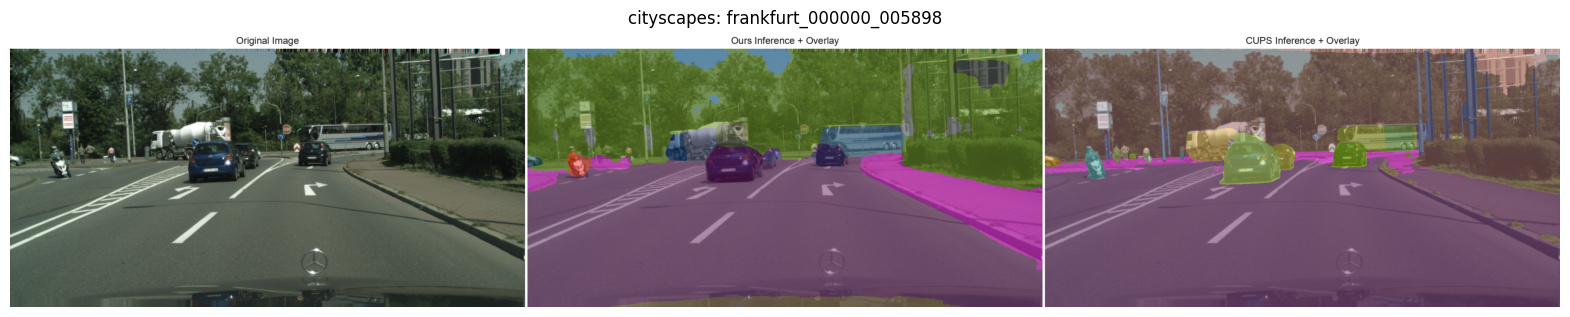

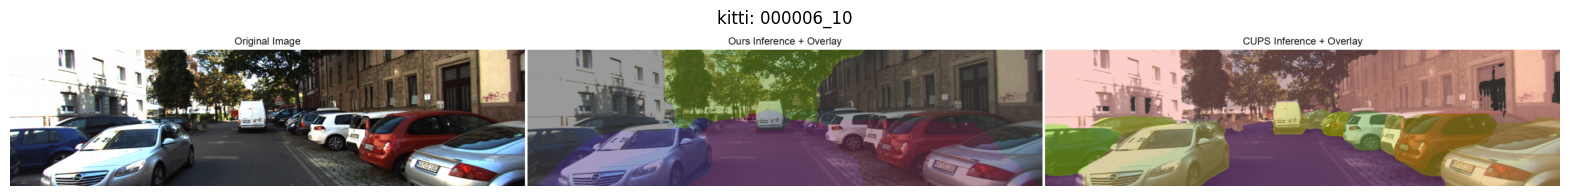

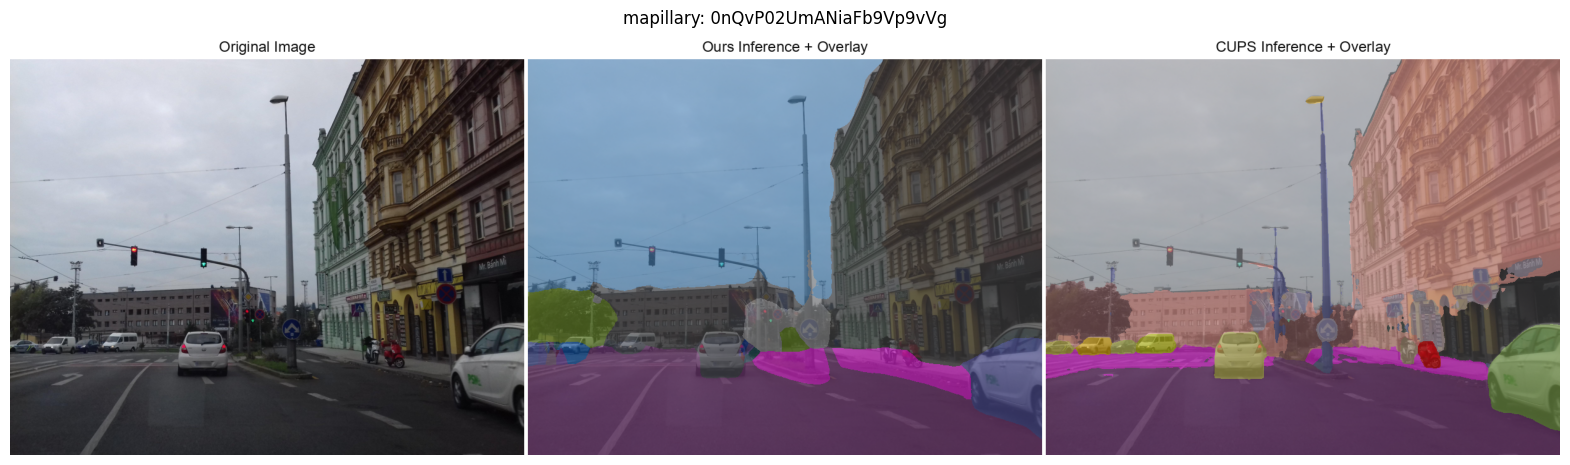

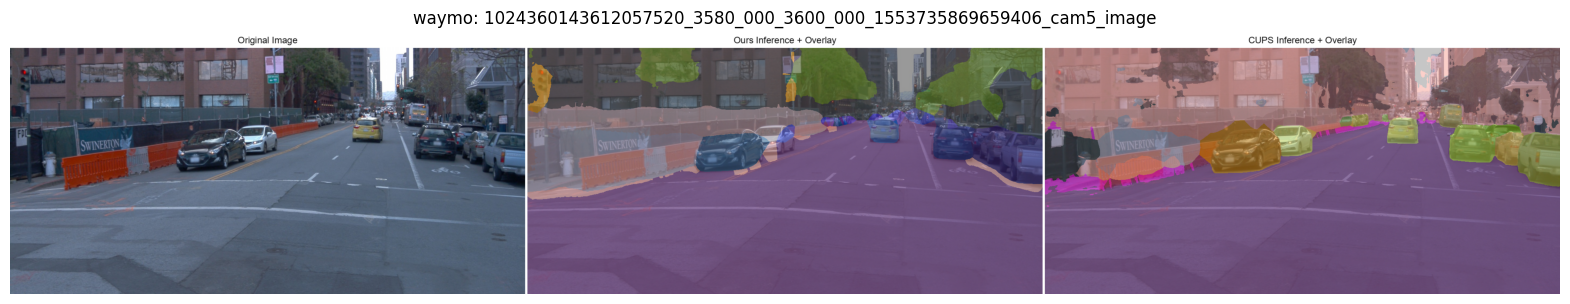

In [22]:
for ds in ['cityscapes', 'kitti', 'mapillary', 'waymo']:
    ds_root = OUTPUT_ROOT / ds
    if not ds_root.exists():
        continue
    triplets = sorted(ds_root.glob('*/triplet.png'))
    if not triplets:
        continue
    img = np.asarray(Image.open(triplets[0]))
    plt.figure(figsize=(20, 6))
    plt.imshow(img); plt.axis('off')
    plt.title(f'{ds}: {triplets[0].parent.name}')
    plt.show()

## 9. Raw 80-Cluster Preview (OURS)

These cells bypass the Cityscapes-27 Hungarian mapping and render OURS directly from raw semantic pseudo-cluster IDs `0..79`. Use this view to inspect what the Stage-4 model predicts before class remapping; keep the mapped CUPS-vs-OURS panels above for benchmark-style qualitative comparison.

In [23]:
RAW80_OUTPUT_ROOT = OUTPUT_ROOT / 'raw80_ours'
RAW80_CLUSTER_COUNT = 80
RAW80_CLUSTER_SEED = 575
RAW80_OVERLAY_ALPHA = 0.55


def render_ours_raw80_semantic(panoptic: torch.Tensor, seed: int = RAW80_CLUSTER_SEED) -> np.ndarray:
    """Render channel 0 directly as OURS raw pseudo-cluster IDs 0..79."""
    semantic = panoptic[..., 0].detach().cpu().to(torch.int64)
    rgb = colorize_id_map(semantic, seed=seed, zero_is_black=False)
    invalid = (semantic < 0) | (semantic >= RAW80_CLUSTER_COUNT)
    if invalid.any():
        rgb[invalid.numpy()] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb


def raw80_summary(panoptic: torch.Tensor) -> dict:
    semantic = panoptic[..., 0].detach().cpu().to(torch.int64)
    valid = semantic[(semantic >= 0) & (semantic < RAW80_CLUSTER_COUNT)]
    invalid = semantic[(semantic < 0) | (semantic >= RAW80_CLUSTER_COUNT)]
    cluster_ids = sorted(int(x) for x in torch.unique(valid).tolist()) if valid.numel() else []
    invalid_ids = sorted(int(x) for x in torch.unique(invalid).tolist()) if invalid.numel() else []
    return {
        'cluster_ids': cluster_ids,
        'num_clusters_present': len(cluster_ids),
        'invalid_ids_rendered_black': invalid_ids,
        'invalid_pixel_count': int(invalid.numel()),
    }


def save_raw80_panel(images: list[np.ndarray], titles: list[str], out_path: Path) -> None:
    pil_images = [Image.fromarray(img).convert('RGB') for img in images]
    w, h = pil_images[0].size
    title_h = 36
    canvas = Image.new('RGB', (w * len(pil_images), h + title_h), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)
    font = _load_triplet_font(size=22)
    for idx, (image, title) in enumerate(zip(pil_images, titles)):
        x = idx * w
        canvas.paste(image, (x, title_h))
        text_box = draw.textbbox((0, 0), title, font=font)
        text_w = text_box[2] - text_box[0]
        draw.text((x + (w - text_w) / 2, 8), title, fill=(20, 20, 20), font=font)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(out_path)


def preview_ours_raw80(image_path: Path, dataset_name: str, image_id: str | None = None, show: bool = True) -> dict:
    image_id = image_id or image_path.stem
    image_t = load_image_tensor(image_path)
    rgb_uint8 = tensor_to_uint8_hwc(image_t)

    with torch.no_grad():
        ours_raw_pano = predict_panoptic(ours_model, image_t, ours_thing_classes, ours_stuff_classes)

    raw80_rgb = render_ours_raw80_semantic(ours_raw_pano)
    raw80_overlay = np.asarray(Image.blend(Image.fromarray(rgb_uint8), Image.fromarray(raw80_rgb), RAW80_OVERLAY_ALPHA))

    mapped_pano = apply_semantic_mapping(ours_raw_pano, SEMANTIC_MAPPINGS.ours)
    mapped_for_render = fill_panoptic_void(mapped_pano) if FILL_VOID else mapped_pano
    mapped_seed = _stable_seed(dataset_name, image_id, 'ours_cityscapes27')
    mapped_overlay = render_overlay(mapped_for_render, image_t, seed=mapped_seed)

    out_dir = RAW80_OUTPUT_ROOT / dataset_name / _safe_image_id(image_id)
    out_dir.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgb_uint8).save(out_dir / 'original.png')
    Image.fromarray(raw80_rgb).save(out_dir / 'ours_raw80_clusters.png')
    Image.fromarray(raw80_overlay).save(out_dir / 'ours_raw80_overlay.png')
    Image.fromarray(mapped_overlay).save(out_dir / 'ours_cityscapes27_overlay.png')
    Image.fromarray(ours_raw_pano[..., 0].detach().cpu().numpy().astype(np.uint16, copy=False)).save(
        out_dir / 'ours_raw80_semantic_ids.png'
    )
    save_raw80_panel(
        [rgb_uint8, raw80_rgb, raw80_overlay, mapped_overlay],
        ['Original', 'OURS raw 80 clusters', 'Raw 80 overlay', 'Cityscapes-27 overlay'],
        out_dir / 'ours_raw80_panel.png',
    )

    summary = raw80_summary(ours_raw_pano)
    summary.update({
        'dataset': dataset_name,
        'image_id': image_id,
        'source_path': str(image_path),
        'out_dir': str(out_dir),
        'checkpoint': str(OURS_CKPT),
    })
    (out_dir / 'ours_raw80_summary.json').write_text(json.dumps(summary, indent=2) + '\n', encoding='utf-8')

    if show:
        panel = np.asarray(Image.open(out_dir / 'ours_raw80_panel.png'))
        plt.figure(figsize=(22, 7))
        plt.imshow(panel)
        plt.axis('off')
        plt.title(f'{dataset_name}: {image_id} | raw clusters present: {summary["num_clusters_present"]}')
        plt.show()

    del image_t, rgb_uint8, ours_raw_pano, raw80_rgb, raw80_overlay, mapped_pano, mapped_for_render, mapped_overlay
    if DEVICE.startswith('cuda'):
        torch.cuda.empty_cache()
    gc.collect()
    return summary


OURS raw 80 clusters:   0%|          | 0/1 [00:00<?, ?it/s]

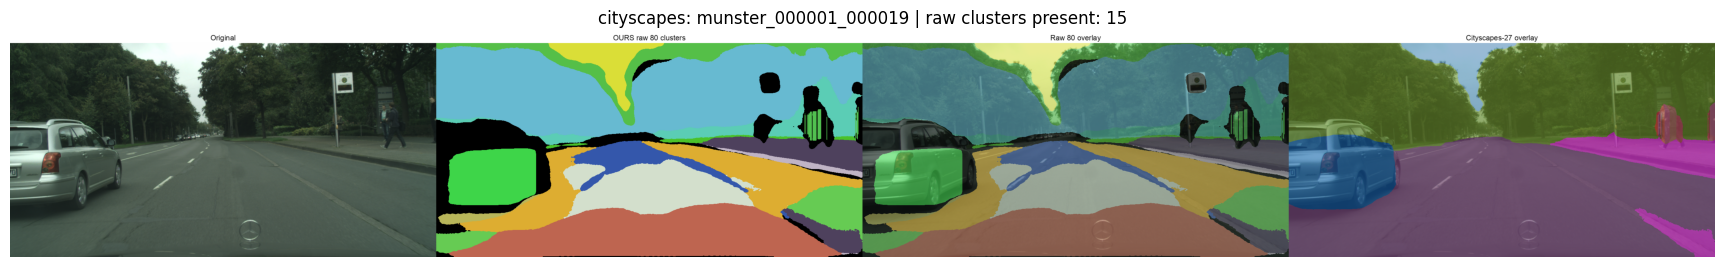

OURS raw 80 clusters: 100%|██████████| 1/1 [00:01<00:00,  1.74s/it]

Raw 80-cluster outputs saved under /Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/raw80_ours/cityscapes/<image_id>/


[{'cluster_ids': [8, 10, 13, 32, 33, 41, 43, 45, 47, 49, 52, 55, 58, 69, 72],
  'num_clusters_present': 15,
  'invalid_ids_rendered_black': [255],
  'invalid_pixel_count': 81760,
  'dataset': 'cityscapes',
  'image_id': 'munster_000001_000019',
  'source_path': '/Users/qbit-glitch/Desktop/datasets/cityscapes/leftImg8bit/val/munster/munster_000001_000019_leftImg8bit.png',
  'out_dir': '/Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/notebooks/qualitative_results/raw80_ours/cityscapes/munster_000001_000019',
  'checkpoint': '/Users/qbit-glitch/Desktop/coding-projects/mbps_panoptic_segmentation/checkpoints/stage4_pathB_focal_w005_gated_v2/best_pq_step=000575.ckpt'}]

In [24]:
# Raw 80-cluster preview. Increase this after checking the first sample.
RAW80_N_PREVIEW = 1

raw80_items = sample_cityscapes()[:RAW80_N_PREVIEW]
RAW80_PREVIEW_ROWS = []
for img_path, img_id in tqdm(raw80_items, desc='OURS raw 80 clusters'):
    RAW80_PREVIEW_ROWS.append(preview_ours_raw80(img_path, 'cityscapes', img_id, show=True))

print(f'Raw 80-cluster outputs saved under {RAW80_OUTPUT_ROOT}/cityscapes/<image_id>/')
RAW80_PREVIEW_ROWS


## 10. Summary

After running all four dataset cells, the directory `notebooks/qualitative_results/` will contain 80 triplets total (20 per dataset). Each `<image_id>/` folder is self-contained: `original.png`, `ours_overlay.png`, `cups_overlay.png`, `triplet.png`, and `source_path.txt`.

For unattended export, run:

```bash
/Users/qbit-glitch/Desktop/datasets/.venv_py310/bin/python \
  scripts/generate_qualitative_ours_vs_cups.py \
  --datasets cityscapes kitti mapillary waymo \
  --n-images 20
```